In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

# Cấu hình hiển thị
%matplotlib inline

# ==========================================
# CẤU HÌNH
# ==========================================
INPUT_FILE = "../../data/processed/train_data_ready.csv"
MODEL_FILE = "../../model/linear_model.pkl"

TARGET_COL = "Gold"
SHIFT_STEPS = 1 # Dự báo giờ tiếp theo

print("✅ Đã import thư viện Scikit-Learn thành công!")

✅ Đã import thư viện Scikit-Learn thành công!


In [2]:
# 1. Đọc dữ liệu
if not os.path.exists(INPUT_FILE):
    print(f"❌ Lỗi: Không thấy file {INPUT_FILE}")
else:
    df = pd.read_csv(INPUT_FILE)
    
    # Bỏ cột Datetime
    if 'Datetime' in df.columns:
        df = df.drop(columns=['Datetime'])

    # 2. Tạo cột Target (Giá tương lai)
    # Dịch ngược cột Gold lên 1 dòng để làm nhãn dự báo
    df['Target'] = df[TARGET_COL].shift(-SHIFT_STEPS)

    # Xóa dòng cuối cùng bị NaN
    df.dropna(inplace=True)
    
    print(f"📂 Dữ liệu sẵn sàng: {df.shape}")
    display(df.tail(3))

📂 Dữ liệu sẵn sàng: (7636, 12)


,Gold,Silver,Brent,Wheat,USD index,RSI,MACD,MACD_SIGNAL,SMA_50,EMA_20,Returns,Target
7633,0.963481,0.954064,0.208386,0.197652,0.196451,0.541471,0.720577,0.708207,0.969027,0.970542,0.505822,0.964662
7634,0.964662,0.953599,0.189518,0.197652,0.195862,0.551154,0.723091,0.713435,0.969502,0.971487,0.449737,0.968501
7635,0.968501,0.951646,0.181551,0.197652,0.196083,0.582050,0.730465,0.719240,0.970058,0.972717,0.481157,0.961020


In [3]:
# 1. Tách X (Đầu vào) và y (Đầu ra)
X = df.drop(columns=['Target'])
y = df['Target']

# 2. Chia tập dữ liệu
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Test set:  {X_test.shape}")

📊 Train set: (6108, 11)
📊 Test set:  (1528, 11)


In [4]:
print("🚀 Bắt đầu Training Linear Regression...")

# Khởi tạo mô hình
model = LinearRegression()

# Huấn luyện (Fit)
model.fit(X_train, y_train)

print("✅ Training hoàn tất!")

# Lưu model
if not os.path.exists("model"):
    os.makedirs("model")
joblib.dump(model, MODEL_FILE)
print(f"💾 Đã lưu model tại {MODEL_FILE}")

🚀 Bắt đầu Training Linear Regression...
✅ Training hoàn tất!
💾 Đã lưu model tại ../../model/linear_model.pkl


In [5]:
# 1. Dự báo
y_pred = model.predict(X_test)

# 2. Tính toán sai số
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📉 KẾT QUẢ ĐÁNH GIÁ:")
print(f"   - RMSE (Sai số chuẩn): {rmse:.5f}")
print(f"   - MAE (Sai số tuyệt đối): {mae:.5f}")
print(f"   - R2 Score (Độ phù hợp): {r2:.5f} (Càng gần 1 càng tốt)")

# 3. HIỂN THỊ TRỌNG SỐ (Coefficients)
# Phần này cực tốt để viết vào báo cáo: Yếu tố nào làm tăng giá vàng?
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight (Hệ số)': model.coef_
})
# Sắp xếp theo độ ảnh hưởng tuyệt đối
coef_df['Abs_Weight'] = coef_df['Weight (Hệ số)'].abs()
coef_df = coef_df.sort_values(by='Abs_Weight', ascending=False).drop(columns=['Abs_Weight'])

print("\n🔍 CÁC YẾU TỐ ẢNH HƯỞNG NHẤT:")
display(coef_df)

📉 KẾT QUẢ ĐÁNH GIÁ:
   - RMSE (Sai số chuẩn): 0.00646
   - MAE (Sai số tuyệt đối): 0.00444
   - R2 Score (Độ phù hợp): 0.99349 (Càng gần 1 càng tốt)

🔍 CÁC YẾU TỐ ẢNH HƯỞNG NHẤT:


,Feature,Weight (Hệ số)
0,Gold,0.962897
9,EMA_20,0.031227
6,MACD,0.004697
8,SMA_50,0.004320
7,MACD_SIGNAL,-0.003017
1,Silver,0.002148
10,Returns,-0.001652
5,RSI,0.001263
2,Brent,-0.000837
4,USD index,0.000458


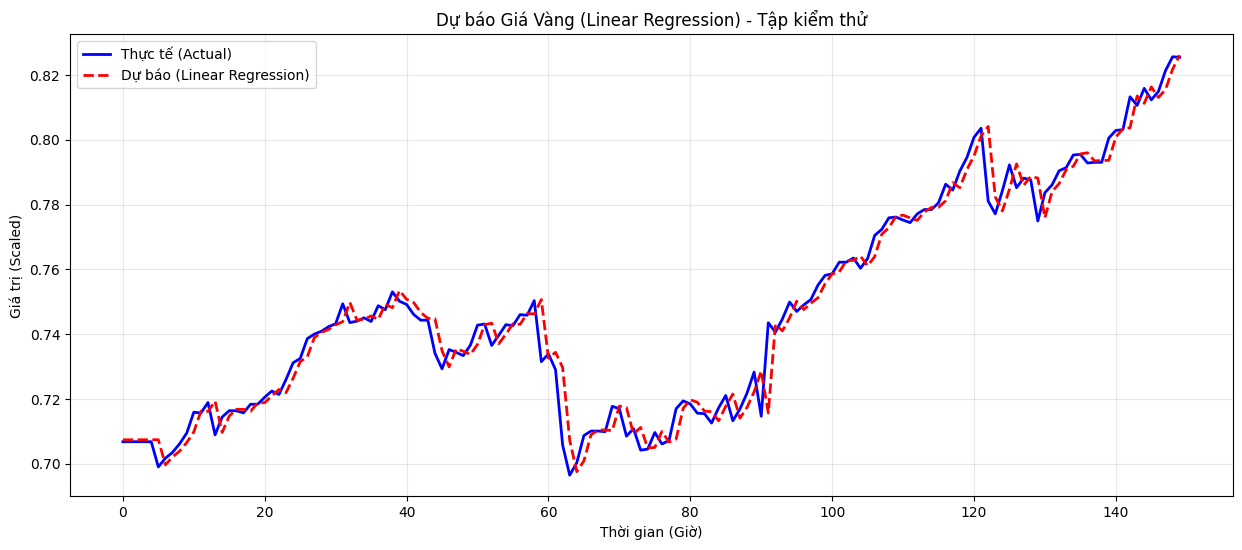

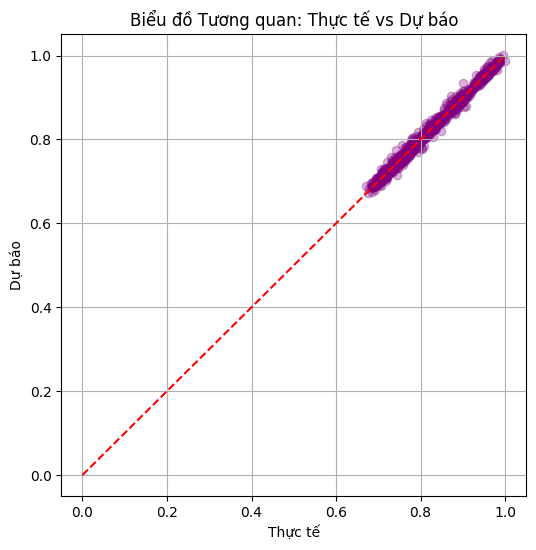

In [6]:
plt.figure(figsize=(15, 6))

# Vẽ 150 điểm đầu tiên của tập Test cho dễ nhìn
limit = 150
plt.plot(y_test.values[:limit], label='Thực tế (Actual)', color='blue', linewidth=2)
plt.plot(y_pred[:limit], label='Dự báo (Linear Regression)', color='red', linestyle='--', linewidth=2)

plt.title('Dự báo Giá Vàng (Linear Regression) - Tập kiểm thử')
plt.xlabel('Thời gian (Giờ)')
plt.ylabel('Giá trị (Scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Vẽ biểu đồ phân tán (Scatter Plot)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Đường chéo hoàn hảo
plt.title('Biểu đồ Tương quan: Thực tế vs Dự báo')
plt.xlabel('Thực tế')
plt.ylabel('Dự báo')
plt.grid(True)
plt.show()